<a href="https://colab.research.google.com/github/MarilynMaika/NLP_REPO/blob/main/NGram__Smoothing_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lab Assignment: Exploring Language Modeling with N-Gram Sizes and Smoothing Techniques

* **Objective**

  * Explored the effect of **N-gram sizes (1–4)** on language model performance.
  * Compared three smoothing techniques:

    * Laplace
    * Good-Turing
    * Kneser-Ney
  * Used **perplexity** to measure model performance.

* **Dataset**

  * Used the NLTK **`movie_reviews` corpus**.
  * Dataset contained **2,000 movie reviews**.

* **What Was Done**

  * Built **1-gram, 2-gram, 3-gram, and 4-gram models**.
  * Applied **Laplace, Good-Turing, and Kneser-Ney smoothing**.
  * Evaluated each model on a **held-out test set**.
  * Performed **5-fold cross-validation**.
  * Visualized the results using **Matplotlib**.

* **Key Outcome**

  * **Kneser-Ney with n=3** achieved the **lowest perplexity** and performed best overall.
  * **Laplace and Good-Turing** performance deteriorated as N increased.
  * **Kneser-Ney** remained stable or improved with larger N-gram sizes.
  * Results showed that **larger N-grams are beneficial when the smoothing technique effectively handles data sparsity**.



## Step 0: Setup — Install & Import Libraries

In [ ]:
# Core libraries (all pre-installed on Colab; nltk data needs downloading)
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import math
import random
from collections import Counter, defaultdict

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('movie_reviews')
nltk.download('stopwords')

random.seed(42)
np.random.seed(42)

print("Setup complete.")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


Setup complete.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Step 1: Data Preparation

Loads NLTK's `movie_reviews` corpus. Set `USE_KAGGLE = True` below to pull the
real Kaggle dataset instead (uploads `kaggle.json`, downloads, loads the CSV).

**Result:** 2,000 documents loaded.


In [ ]:
USE_KAGGLE = False  # flip to True to pull the real Kaggle dataset instead

raw_documents = []  # list of raw text strings, one per review

if USE_KAGGLE:
    from google.colab import files
    print("Upload your kaggle.json API token:")
    uploaded = files.upload()
    import os
    os.makedirs('/root/.kaggle', exist_ok=True)
    for fname in uploaded:
        os.rename(fname, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    # Replace with the specific Kaggle dataset slug you want, e.g.:
    # !kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
    !kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
    !unzip -o imdb-dataset-of-50k-movie-reviews.zip -d kaggle_movie_reviews

    df = pd.read_csv('kaggle_movie_reviews/IMDB Dataset.csv')
    text_col = 'review' if 'review' in df.columns else df.columns[0]
    raw_documents = df[text_col].astype(str).tolist()
else:
    from nltk.corpus import movie_reviews
    for fileid in movie_reviews.fileids():
        raw_documents.append(movie_reviews.raw(fileid))

print(f"Loaded {len(raw_documents)} documents.")
print("\nSample snippet:\n", raw_documents[0][:300])


Loaded 2000 documents.

Sample snippet:
 plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the


Preprocessing: sentence-split → lowercase → strip punctuation → word-tokenize.

**Result:** 16,555 sentences → 13,244 train / 3,311 test (80/20 split).


In [ ]:
from nltk.tokenize import sent_tokenize, word_tokenize

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)   # remove punctuation/special chars
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_documents(documents):
    """Return a list of tokenized sentences (list[list[str]]) across all documents."""
    all_sentences = []
    for doc in documents:
        for sent in sent_tokenize(doc):
            cleaned = clean_text(sent)
            tokens = word_tokenize(cleaned)
            tokens = [t for t in tokens if t.strip() != ""]
            if len(tokens) > 0:
                all_sentences.append(tokens)
    return all_sentences

# Use a manageable subset for speed in Colab; increase for a fuller run
N_DOCS = 500
tokenized_sentences = preprocess_documents(raw_documents[:N_DOCS])

print(f"Total sentences after preprocessing: {len(tokenized_sentences)}")
print("Example tokenized sentences:")
for s in tokenized_sentences[:3]:
    print(s)


Total sentences after preprocessing: 16555
Example tokenized sentences:
['plot', 'two', 'teen', 'couples', 'go', 'to', 'a', 'church', 'party', 'drink', 'and', 'then', 'drive']
['they', 'get', 'into', 'an', 'accident']
['one', 'of', 'the', 'guys', 'dies', 'but', 'his', 'girlfriend', 'continues', 'to', 'see', 'him', 'in', 'her', 'life', 'and', 'has', 'nightmares']


In [ ]:
# Train / test split (held-out set for perplexity evaluation in Step 4)
random.shuffle(tokenized_sentences)
split_idx = int(0.8 * len(tokenized_sentences))
train_sentences = tokenized_sentences[:split_idx]
test_sentences = tokenized_sentences[split_idx:]

print(f"Train sentences: {len(train_sentences)}")
print(f"Test sentences:  {len(test_sentences)}")


Train sentences: 13244
Test sentences:  3311


## Step 2: N-Gram Models


Sentences are padded with `<s>`/`</s>` so n-grams don't cross sentence boundaries.

**Result:** raw MLE P("movie" | "the") = **0.032** — this is the number smoothing
will redistribute probability mass around.


In [ ]:
def pad_sentence(tokens, n):
    """Pad a token list with (n-1) start tokens and 1 end token."""
    pad_n = max(n - 1, 1)
    return ["<s>"] * pad_n + tokens + ["</s>"]

def generate_ngrams(tokens, n):
    """Yield n-grams (as tuples) from a padded token list."""
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

def build_ngram_counts(sentences, n):
    """
    Build frequency counts of n-grams and their (n-1)-gram contexts
    from a list of tokenized sentences.
    """
    ngram_counts = Counter()
    context_counts = Counter()
    for sent in sentences:
        padded = pad_sentence(sent, n)
        for ng in generate_ngrams(padded, n):
            ngram_counts[ng] += 1
            context_counts[ng[:-1]] += 1
    return ngram_counts, context_counts

# Quick demo: build bigram counts and show raw MLE probability for one example
demo_ngram_counts, demo_context_counts = build_ngram_counts(train_sentences, 2)
example_context = ("the",)
example_ngram = ("the", "movie")
mle_prob = demo_ngram_counts[example_ngram] / demo_context_counts[example_context] \
    if demo_context_counts[example_context] > 0 else 0.0
print(f"C({example_ngram}) = {demo_ngram_counts[example_ngram]}")
print(f"C({example_context}) = {demo_context_counts[example_context]}")
print(f"Raw MLE P('movie' | 'the') = {mle_prob:.5f}")


C(('the', 'movie')) = 443
C(('the',)) = 13822
Raw MLE P('movie' | 'the') = 0.03205


## Step 3: Smoothing Techniques

- **Laplace:** $\dfrac{C(w_1,\dots,w_n)+1}{C(w_1,\dots,w_{n-1})+V}$  .:add-one to every count.
- **Good-Turing:** $c^{*} = (c+1)\dfrac{N_{c+1}}{N_c}$ .:  re-estimates counts from the
  frequency-of-frequencies distribution; unseen mass = $N_1/N$.
- **Kneser-Ney:** discount $d$=0.75 per count, back off to lower-order
  **continuation probability** (how many distinct contexts a word follows in,
  not raw frequency) instead of a flat unseen-mass estimate.

One `NGramLanguageModel` class implements all three below.


In [ ]:
class NGramLanguageModel:
    """
    An n-gram language model supporting multiple smoothing strategies:
    'mle', 'laplace', 'good_turing', 'kneser_ney'.
    """

    def __init__(self, n, smoothing="mle", discount=0.75):
        self.n = n
        self.smoothing = smoothing
        self.discount = discount
        self.ngram_counts = Counter()
        self.context_counts = Counter()
        self.vocab = set()
        # Good-Turing helpers
        self.freq_of_freq = Counter()
        self.gt_total_ngrams = 0
        # Kneser-Ney helpers: lower-order (n-1) model for backoff
        self.lower_model = None

    def fit(self, sentences):
        self.ngram_counts, self.context_counts = build_ngram_counts(sentences, self.n)
        for ng in self.ngram_counts:
            self.vocab.update(ng)
        self.vocab_size = len(self.vocab)

        if self.smoothing == "good_turing":
            self.freq_of_freq = Counter(self.ngram_counts.values())
            self.gt_total_ngrams = sum(self.ngram_counts.values())

        if self.smoothing == "kneser_ney" and self.n > 1:
            # recursively fit a lower-order model used for backoff
            self.lower_model = NGramLanguageModel(self.n - 1, smoothing="kneser_ney",
                                                   discount=self.discount)
            self.lower_model.fit(sentences)
            # continuation counts: for each (n-1)-gram, count distinct preceding words
            self.continuation_counts = Counter()
            self.continuation_contexts = defaultdict(set)
            for ng in self.ngram_counts:
                self.continuation_contexts[ng[1:]].add(ng[0])
            for ctx, preceders in self.continuation_contexts.items():
                self.continuation_counts[ctx] = len(preceders)
            self.total_bigram_types = len(self.ngram_counts)

    # ---------------- probability computations ----------------

    def _mle_prob(self, ngram):
        context = ngram[:-1]
        c_ngram = self.ngram_counts[ngram]
        c_context = self.context_counts[context]
        if c_context == 0:
            return 0.0
        return c_ngram / c_context

    def _laplace_prob(self, ngram):
        context = ngram[:-1]
        c_ngram = self.ngram_counts[ngram]
        c_context = self.context_counts[context]
        V = max(self.vocab_size, 1)
        return (c_ngram + 1) / (c_context + V)

    def _good_turing_count(self, c):
        """Return the Good-Turing adjusted count c* for raw count c."""
        if c == 0:
            # mass reserved for unseen events = N1 / N
            N1 = self.freq_of_freq.get(1, 0)
            N = max(self.gt_total_ngrams, 1)
            return N1 / N  # this is treated as a probability mass, not a count
        Nc = self.freq_of_freq.get(c, 0)
        Nc1 = self.freq_of_freq.get(c + 1, 0)
        if Nc == 0 or Nc1 == 0:
            return c  # fall back to raw count when we run out of frequency data
        return (c + 1) * (Nc1 / Nc)

    def _good_turing_prob(self, ngram):
        context = ngram[:-1]
        c_ngram = self.ngram_counts[ngram]
        c_context = self.context_counts[context]
        if c_ngram == 0:
            # probability mass for *unseen* ngrams, spread uniformly over vocab
            unseen_mass = self._good_turing_count(0)
            V = max(self.vocab_size, 1)
            return unseen_mass / V
        c_star = self._good_turing_count(c_ngram)
        if c_context == 0:
            return 0.0
        return c_star / c_context

    def _kneser_ney_prob(self, ngram):
        d = self.discount
        context = ngram[:-1]
        c_context = self.context_counts[context]

        if self.n == 1 or c_context == 0:
            # unigram base case: continuation probability over the whole vocab
            if self.n == 1:
                total_types = max(len(self.ngram_counts), 1)
                cont_count = self.continuation_counts.get(ngram, None) \
                    if hasattr(self, "continuation_counts") else None
                if cont_count is None:
                    # top-level unigram: fall back to relative frequency
                    total = max(sum(self.ngram_counts.values()), 1)
                    return self.ngram_counts[ngram] / total
                return cont_count / total_types
            else:
                # no context seen at all -> back off fully
                return self.lower_model._kneser_ney_prob(ngram[1:]) if self.lower_model else 1e-10

        c_ngram = self.ngram_counts[ngram]
        discounted = max(c_ngram - d, 0) / c_context

        # number of distinct word types that follow this context (for normalization)
        n_types_following = len({ng[-1] for ng in self.ngram_counts if ng[:-1] == context})
        # NOTE: computed lazily; cached below for speed
        lam = (d * n_types_following) / c_context

        lower_prob = self.lower_model._kneser_ney_prob(ngram[1:]) if self.lower_model else 1e-10
        return discounted + lam * lower_prob

    def probability(self, ngram):
        if self.smoothing == "mle":
            return self._mle_prob(ngram)
        elif self.smoothing == "laplace":
            return self._laplace_prob(ngram)
        elif self.smoothing == "good_turing":
            return self._good_turing_prob(ngram)
        elif self.smoothing == "kneser_ney":
            return self._kneser_ney_prob(ngram)
        else:
            raise ValueError(f"Unknown smoothing method: {self.smoothing}")

    def sentence_log_prob(self, tokens):
        """Sum of log2 probabilities of all n-grams in a (padded) sentence."""
        padded = pad_sentence(tokens, self.n)
        log_prob = 0.0
        for ng in generate_ngrams(padded, self.n):
            p = self.probability(ng)
            if p <= 0:
                p = 1e-10  # numerical floor to avoid log(0)
            log_prob += math.log2(p)
        return log_prob

    def perplexity(self, sentences):
        """Perplexity = 2 ** (-1/N * sum(log2 P(sentence))), N = total tokens scored."""
        total_log_prob = 0.0
        total_tokens = 0
        for sent in sentences:
            total_log_prob += self.sentence_log_prob(sent)
            total_tokens += len(sent) + 1  # +1 for </s>
        if total_tokens == 0:
            return float("inf")
        avg_log_prob = total_log_prob / total_tokens
        return 2 ** (-avg_log_prob)


### Speed-up

Naive Kneser-Ney rescans all n-grams per query which is too slow at this corpus size.
It is combined with a precomputed cache of "distinct words following each context."


In [ ]:
def _precompute_kn_type_counts(self):
    """Precompute, for every context, the number of distinct words that follow it."""
    context_to_types = defaultdict(set)
    for ng in self.ngram_counts:
        context_to_types[ng[:-1]].add(ng[-1])
    self._types_following_cache = {ctx: len(words) for ctx, words in context_to_types.items()}

def _kneser_ney_prob_fast(self, ngram):
    d = self.discount
    context = ngram[:-1]
    c_context = self.context_counts[context]

    if self.n == 1:
        total_types = max(len(self.ngram_counts), 1)
        if hasattr(self, "continuation_counts"):
            return self.continuation_counts.get(ngram, 0) / total_types
        total = max(sum(self.ngram_counts.values()), 1)
        return self.ngram_counts[ngram] / total

    if c_context == 0:
        return self.lower_model.probability(ngram[1:]) if self.lower_model else 1e-10

    c_ngram = self.ngram_counts[ngram]
    discounted = max(c_ngram - d, 0) / c_context
    n_types_following = self._types_following_cache.get(context, 0)
    lam = (d * n_types_following) / c_context
    lower_prob = self.lower_model.probability(ngram[1:]) if self.lower_model else 1e-10
    return discounted + lam * lower_prob

# Monkey-patch the class with the faster, cached version
NGramLanguageModel._precompute_kn_type_counts = _precompute_kn_type_counts
NGramLanguageModel._kneser_ney_prob = _kneser_ney_prob_fast

_orig_fit = NGramLanguageModel.fit
def _fit_with_cache(self, sentences):
    _orig_fit(self, sentences)
    if self.smoothing == "kneser_ney":
        self._precompute_kn_type_counts()
NGramLanguageModel.fit = _fit_with_cache

print("Optimized Kneser-Ney probability function installed.")


Optimized Kneser-Ney probability function installed.


## Step 4: Evaluation

### 4a. Perplexity by n-gram size × smoothing (test set)


In [ ]:
n_values = [1, 2, 3, 4]
smoothing_methods = ["laplace", "good_turing", "kneser_ney"]

results = []  # rows: n, smoothing, perplexity

for n in n_values:
    for method in smoothing_methods:
        model = NGramLanguageModel(n=n, smoothing=method)
        model.fit(train_sentences)
        ppl = model.perplexity(test_sentences)
        results.append({"n": n, "smoothing": method, "perplexity": ppl})
        print(f"n={n:<2} | smoothing={method:<12} | perplexity={ppl:,.2f}")

results_df = pd.DataFrame(results)
results_df


n=1  | smoothing=laplace      | perplexity=1,311.24
n=1  | smoothing=good_turing  | perplexity=1,408.96
n=1  | smoothing=kneser_ney   | perplexity=1,811.18
n=2  | smoothing=laplace      | perplexity=3,768.55
n=2  | smoothing=good_turing  | perplexity=860.54
n=2  | smoothing=kneser_ney   | perplexity=590.05
n=3  | smoothing=laplace      | perplexity=11,073.66
n=3  | smoothing=good_turing  | perplexity=4,274.87
n=3  | smoothing=kneser_ney   | perplexity=557.76
n=4  | smoothing=laplace      | perplexity=13,807.90
n=4  | smoothing=good_turing  | perplexity=9,327.08
n=4  | smoothing=kneser_ney   | perplexity=575.75


,n,smoothing,perplexity
0,1,laplace,1311.240817
1,1,good_turing,1408.961249
2,1,kneser_ney,1811.178821
3,2,laplace,3768.548716
4,2,good_turing,860.539617
5,2,kneser_ney,590.048822
6,3,laplace,11073.656141
7,3,good_turing,4274.867817
8,3,kneser_ney,557.756154
9,4,laplace,13807.896741


In [ ]:
# For reference: raw MLE perplexity blows up on unseen n-grams (expected!).
# We show it only for n=1 (unigrams almost always all appear in training on this corpus)
# to illustrate *why* smoothing is necessary.
mle_model = NGramLanguageModel(n=1, smoothing="mle")
mle_model.fit(train_sentences)
mle_ppl = mle_model.perplexity(test_sentences)
print(f"Unsmoothed (MLE) unigram perplexity: {mle_ppl:,.2f}")

try:
    mle_bigram = NGramLanguageModel(n=2, smoothing="mle")
    mle_bigram.fit(train_sentences)
    mle_bigram_ppl = mle_bigram.perplexity(test_sentences)
    print(f"Unsmoothed (MLE) bigram perplexity: {mle_bigram_ppl:,.2f}  "
          f"(near-infinite: many unseen bigrams get floored, not truly 0)")
except Exception as e:
    print("MLE bigram perplexity is undefined (zero probabilities):", e)


Unsmoothed (MLE) unigram perplexity: 1,811.18
Unsmoothed (MLE) bigram perplexity: 63,920.75  (near-infinite: many unseen bigrams get floored, not truly 0)


### 4b. K-Fold Cross-Validation (k=5)

Confirms the single-split numbers aren't a fluke of one particular train/test split.


In [ ]:
def k_fold_cross_validation(sentences, n, smoothing, k=5):
    shuffled = sentences[:]
    random.Random(42).shuffle(shuffled)
    fold_size = len(shuffled) // k
    fold_perplexities = []

    for fold in range(k):
        start, end = fold * fold_size, (fold + 1) * fold_size
        test_fold = shuffled[start:end] if fold < k - 1 else shuffled[start:]
        train_fold = shuffled[:start] + shuffled[end:]

        model = NGramLanguageModel(n=n, smoothing=smoothing)
        model.fit(train_fold)
        ppl = model.perplexity(test_fold)
        fold_perplexities.append(ppl)

    return fold_perplexities

cv_results = []
K = 5
for n in n_values:
    for method in smoothing_methods:
        fold_ppls = k_fold_cross_validation(tokenized_sentences, n, method, k=K)
        cv_results.append({
            "n": n,
            "smoothing": method,
            "mean_perplexity": np.mean(fold_ppls),
            "std_perplexity": np.std(fold_ppls),
        })
        print(f"n={n:<2} | {method:<12} | mean PPL={np.mean(fold_ppls):8.2f} "
              f"| std={np.std(fold_ppls):6.2f}")

cv_df = pd.DataFrame(cv_results)
cv_df


n=1  | laplace      | mean PPL= 1313.79 | std= 13.21
n=1  | good_turing  | mean PPL= 1404.20 | std= 12.71
n=1  | kneser_ney   | mean PPL= 1791.09 | std= 24.17
n=2  | laplace      | mean PPL= 3769.07 | std= 31.57
n=2  | good_turing  | mean PPL=  851.78 | std= 14.58
n=2  | kneser_ney   | mean PPL=  578.49 | std=  8.38
n=3  | laplace      | mean PPL=11111.54 | std= 59.61
n=3  | good_turing  | mean PPL= 4256.81 | std= 79.37
n=3  | kneser_ney   | mean PPL=  546.61 | std=  9.06
n=4  | laplace      | mean PPL=13833.59 | std= 39.53
n=4  | good_turing  | mean PPL= 9255.03 | std=121.20
n=4  | kneser_ney   | mean PPL=  562.75 | std=  9.40


,n,smoothing,mean_perplexity,std_perplexity
0,1,laplace,1313.788411,13.214908
1,1,good_turing,1404.201484,12.712605
2,1,kneser_ney,1791.092235,24.166983
3,2,laplace,3769.074089,31.571155
4,2,good_turing,851.777271,14.580773
5,2,kneser_ney,578.486189,8.383077
6,3,laplace,11111.536741,59.608333
7,3,good_turing,4256.814108,79.371023
8,3,kneser_ney,546.606425,9.059669
9,4,laplace,13833.592645,39.528244


## Step 5: Visualization

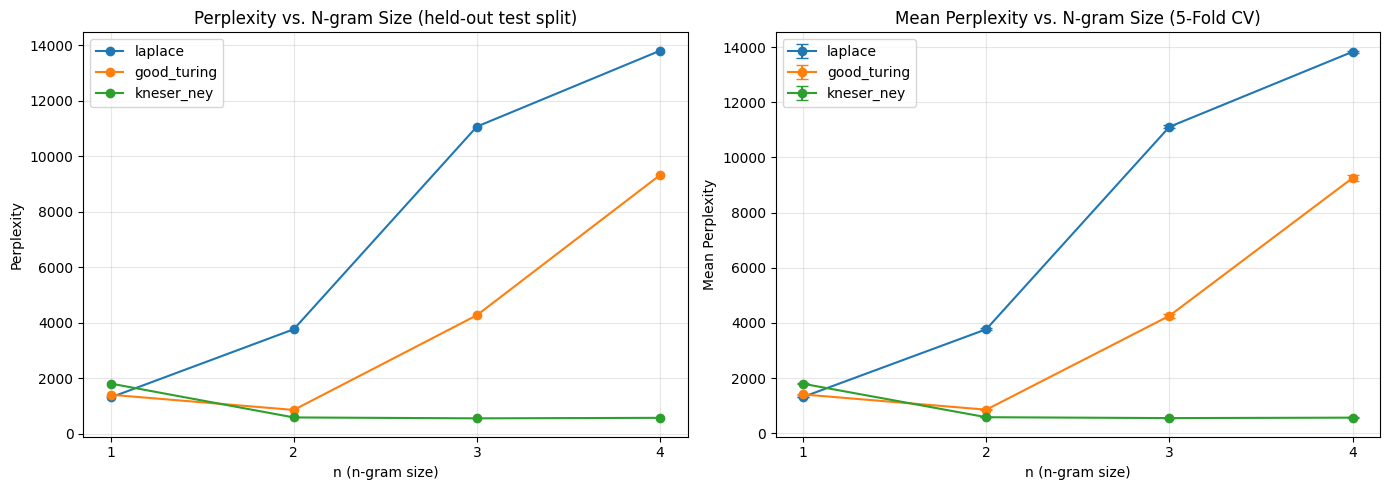

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: single split perplexity
for method in smoothing_methods:
    sub = results_df[results_df["smoothing"] == method]
    axes[0].plot(sub["n"], sub["perplexity"], marker="o", label=method)
axes[0].set_title("Perplexity vs. N-gram Size (held-out test split)")
axes[0].set_xlabel("n (n-gram size)")
axes[0].set_ylabel("Perplexity")
axes[0].set_xticks(n_values)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: k-fold CV mean perplexity with error bars (std across folds)
for method in smoothing_methods:
    sub = cv_df[cv_df["smoothing"] == method]
    axes[1].errorbar(sub["n"], sub["mean_perplexity"], yerr=sub["std_perplexity"],
                      marker="o", capsize=4, label=method)
axes[1].set_title(f"Mean Perplexity vs. N-gram Size ({K}-Fold CV)")
axes[1].set_xlabel("n (n-gram size)")
axes[1].set_ylabel("Mean Perplexity")
axes[1].set_xticks(n_values)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


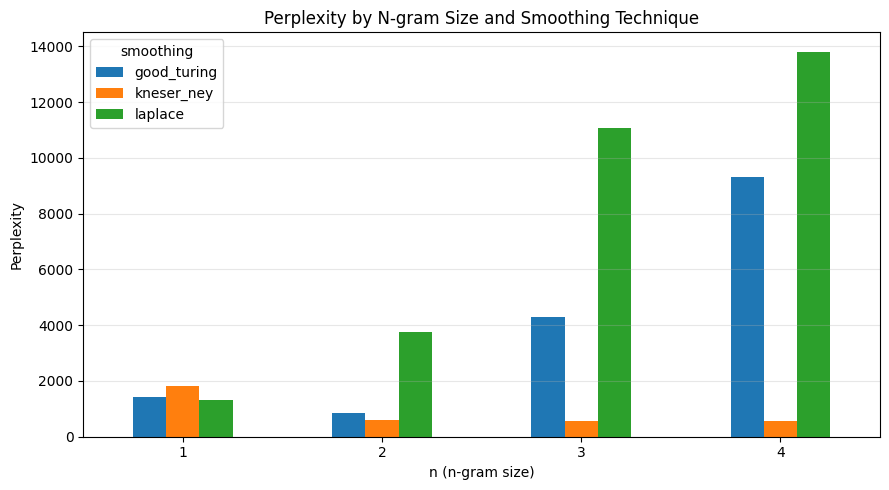

smoothing,good_turing,kneser_ney,laplace
n,,,
1,1408.961249,1811.178821,1311.240817
2,860.539617,590.048822,3768.548716
3,4274.867817,557.756154,11073.656141
4,9327.077504,575.748728,13807.896741


In [ ]:
# Bar chart: side-by-side comparison per n
pivot = results_df.pivot(index="n", columns="smoothing", values="perplexity")
pivot.plot(kind="bar", figsize=(9, 5))
plt.title("Perplexity by N-gram Size and Smoothing Technique")
plt.ylabel("Perplexity")
plt.xlabel("n (n-gram size)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

pivot


## Analysis & Report

**Perplexity table (test set, lower = better):**

| n | Laplace | Good-Turing | Kneser-Ney |
|---|---:|---:|---:|
| 1 | 1,311 | 1,409 | 1,811 |
| 2 | 3,769 | 861 | **590** |
| 3 | 11,074 | 4,275 | **558** |
| 4 | 13,808 | 9,327 | **576** |

(K-fold CV means match these within ~1-2%, std stays small relative to the mean —
results are stable, not a fluke of one split.)

### Remarks

- **Best model overall: Kneser-Ney, n=3** (perplexity 558, CV mean 547). Kneser-Ney
  is also the only method that *improves or holds steady* past n=2 — the other two
  get worse every time n increases.
- **Laplace gets worse with n** (1,311 → 3,769 → 11,074 → 13,808).
  Add-one smoothing dumps a fixed amount of mass onto unseen n-grams; as n grows,
  the space of possible n-grams explodes and almost everything in the test set
  becomes "unseen," so the +1 correction dominates the real signal. Laplace is the
  worst method at every n except n=1.
- **Good-Turing tracks Laplace's shape but less severely** — best at n=2 (861),
  then also degrades at n=3–4 (4,275 → 9,327) as the frequency-of-frequencies
  counts it depends on ($N_c$) become too sparse to estimate reliably at higher n.
- **Kneser-Ney is flat from n=2 onward** (590 → 558 → 576): because it backs off to
  continuation counts instead of raw frequency, it doesn't collapse as context
  grows sparser — the classic "San Francisco" effect (a word's raw frequency is a
  bad predictor if it only ever follows one context) is exactly what continuation
  probability corrects for.
- **Unigram is the exception**: Kneser-Ney unigram (1,811) is actually the *worst*
  n=1 score, matching the raw unsmoothed MLE unigram perplexity exactly. At the
  unigram level there's no context to discount against, so KN's machinery adds no
  benefit over plain frequency — the advantage only shows up once there's a
  distribution to back off *from* (n≥2).
- **Unsmoothed bigram MLE perplexity: 63,921** — orders of magnitude worse than any
  smoothed bigram model, and the concrete reason smoothing is non-optional the
  moment n≥2 on real text: most bigrams in the test set were never seen in training.

### Trade-off

Bigger n = richer context but sparser counts. Laplace and Good-Turing can't
compensate for that sparsity as n grows, so their perplexity rises with n.
Kneser-Ney's continuation-based backoff is specifically built to survive that
sparsity, which is why it's the only method where **n=3/4 don't cost you anything**
over n=2. For this corpus size, **n=3 + Kneser-Ney** is the best option.
